In [1]:

from imports import *
from agent_class import FullAgent, FullAgent2
from simulation_class import Simulation, Simulation2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


In [2]:

def run_multiple_simulations(n_runs, params, steps=500, title_suffix=""):
    final_states = []
    time_series = []
    reports = []
    
    print(f"Running {n_runs} simulations for {title_suffix}...")
    
    for i in range(n_runs):
        # We must set plot=False to handle plotting manually
        current_params = params.copy()
        current_params['plot'] = False
        
        # Initialize simulation
        sim = Simulation(**current_params)
        sim.run(steps, plot_grid=False)
        
        # Collect final state proportions
        s_prop = sim.s_proportions[-1] if sim.s_proportions else 0
        i_prop = sim.i_proportions[-1] if sim.i_proportions else 0
        d_prop = sim.d_proportions[-1] if sim.d_proportions else 0
        
        final_states.append({'Run': i, 'State': 'S', 'Proportion': s_prop})
        final_states.append({'Run': i, 'State': 'I', 'Proportion': i_prop})
        final_states.append({'Run': i, 'State': 'D', 'Proportion': d_prop})
        
        # Collect time series
        df_ts = pd.DataFrame({
            'S': sim.s_proportions,
            'I': sim.i_proportions,
            'D': sim.d_proportions
        })
        df_ts['Run'] = i
        df_ts['Step'] = df_ts.index
        time_series.append(df_ts)
        
        # Collect standard report
        report = sim.generate_simulation_report()
        reports.append(report)
        
    final_df = pd.DataFrame(final_states)
    time_df = pd.concat(time_series, ignore_index=True)
    
    # Average report
    avg_report = np.mean(reports, axis=0) if reports else []
    
    # Plotting
    plot_results(final_df, time_df, title_suffix)
    
    return avg_report

def plot_results(final_df, time_df, title_suffix=""):
    # Reduce figsize to compact the plots horizontally
    fig = plt.figure(figsize=(14, 7))
    
    # 3D Bar Plot for Final States
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Map states to numeric for x-axis
    state_map = {'S': 0, 'I': 1, 'D': 2}
    final_df['StateNum'] = final_df['State'].map(state_map)
    
    colors = {'S': 'green', 'I': 'red', 'D': 'black'}
    
    # We plot each state group separately for color mapping
    for state in ['S', 'I', 'D']:
        subset = final_df[final_df['State'] == state]
        
        x = subset['StateNum']
        y = subset['Run']
        z = np.zeros(len(subset))
        
        dx = 0.4  # width of bars
        dy = 0.4  # depth of bars
        dz = subset['Proportion']
        
        ax1.bar3d(x, y, z, dx, dy, dz, color=colors[state], alpha=0.7)
    
    ax1.set_xlabel('State', labelpad=10)
    ax1.set_ylabel('Run ID', labelpad=10)
    ax1.set_zlabel('Proportion', labelpad=10)
    ax1.set_title(f'Final Agent State Proportions (3D Bar)\n{title_suffix}')
    ax1.set_xticks([0.2, 1.2, 2.2])
    ax1.set_xticklabels(['S', 'I', 'D'])
    ax1.set_zlim(0, 1)
    
    # 3D Smoothed Time Series Plot
    ax2 = fig.add_subplot(122, projection='3d')
    
    runs = time_df['Run'].unique()
    for run in runs:
        run_data = time_df[time_df['Run'] == run]
        # Smoothing
        window = 5
        s_smooth = run_data['S'].rolling(window=window, min_periods=1).mean()
        i_smooth = run_data['I'].rolling(window=window, min_periods=1).mean()
        d_smooth = run_data['D'].rolling(window=window, min_periods=1).mean()
        
        step = run_data['Step']
        
        ax2.plot(step, [run]*len(step), s_smooth, color='green', alpha=0.3)
        ax2.plot(step, [run]*len(step), i_smooth, color='red', alpha=0.3)
        ax2.plot(step, [run]*len(step), d_smooth, color='black', alpha=0.3)
        
    ax2.set_title(f'Smoothed State Proportions Over Time (3D)\n{title_suffix}', pad=20)
    
    # High labelpad to ensure visibility
    # The user specifically mentioned the "Y vertical axis" (which is Z in 3D) has no label.
    # We increase padding significantly for Z and rotate it if possible, though matplotlib 3d rotation is auto.
    ax2.set_xlabel('Time Steps', labelpad=15)
    ax2.set_ylabel('Run ID', labelpad=15)
    ax2.set_zlabel('Proportion', labelpad=20) # Increased from 12 to 20
    ax2.set_zlim(0, 1)
    
    # Create legend manually
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='green', lw=2),
                    Line2D([0], [0], color='red', lw=2),
                    Line2D([0], [0], color='black', lw=2)]
    ax2.legend(custom_lines, ['S', 'I', 'D'], loc='upper left', bbox_to_anchor=(0.0, 0.9))
    
    # Adjust tight_layout arguments to leave space for labels
    # rect=[left, bottom, right, top]
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.subplots_adjust(wspace=0.1)
    
    plt.show()


In [3]:
N_RUNS = 50
SIM_STEPS = 500

# Cyclical Case (SIS)
- No death
- 0.1 vulnerable
- No vaccination
- No viral aging
- No immunity adaptation

Running 50 simulations for Cyclical Case (SIS)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


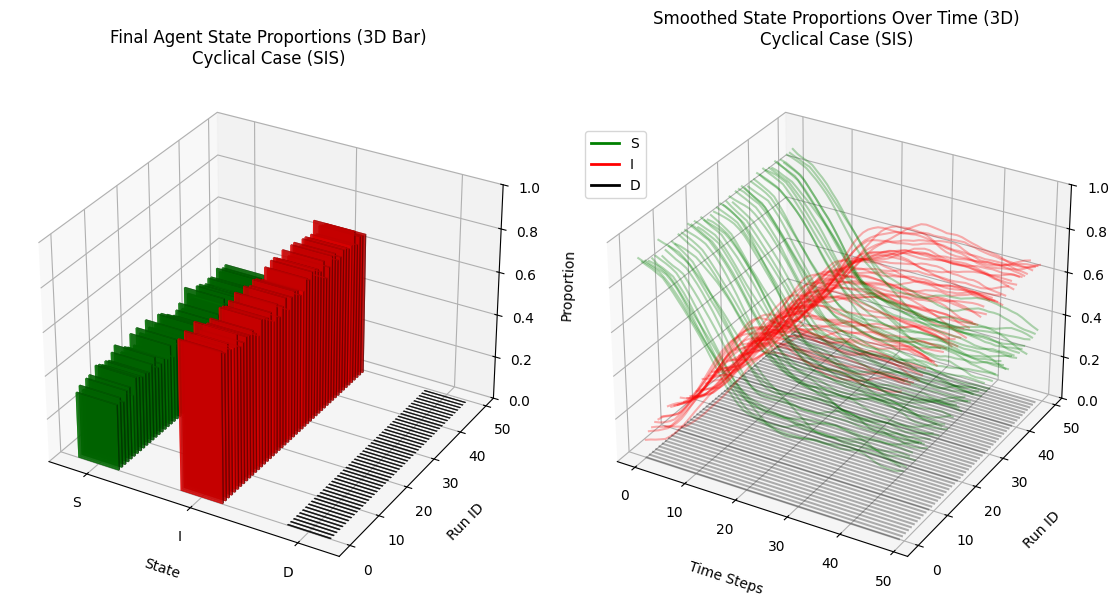

array([4.9000000e+01, 0.0000000e+00, 7.0912000e-01, 2.7694140e+01,
       4.7980400e+00, 1.1500000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 4.9208000e+02, 9.0954000e+02, 8.9720000e+01,
       8.1982000e+02, 1.8482759e+00])

In [4]:

params_sis = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0, immune_adaptation_effect=0
)
run_multiple_simulations(N_RUNS, params_sis, steps=SIM_STEPS, title_suffix="Cyclical Case (SIS)")


# Death (SID)
- Death prob 0.01
- Otherwise same as SIS

Running 50 simulations for Death (SID)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


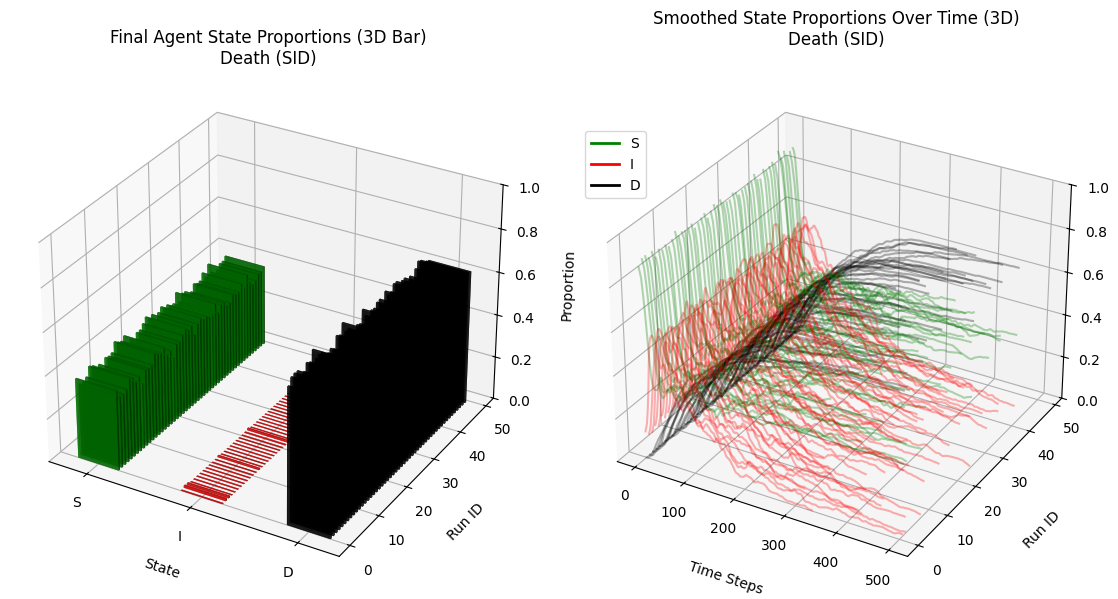

array([3.83820000e+02, 6.38840000e-01, 5.75920000e-01, 6.25126800e+01,
       1.48476000e+01, 3.00724000e+00, 6.30013312e-01, 7.14164125e-01,
       0.00000000e+00, 4.99840000e+02, 1.82374000e+03, 1.79860000e+02,
       1.64388000e+03, 3.64858390e+00])

In [5]:

params_sid = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0, immune_adaptation_effect=0
)
run_multiple_simulations(N_RUNS, params_sid, steps=SIM_STEPS, title_suffix="Death (SID)")


# Viral Aging and Immunity, but no Death (SIIM)

Running 50 simulations for Viral Aging & Immunity (No Death)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


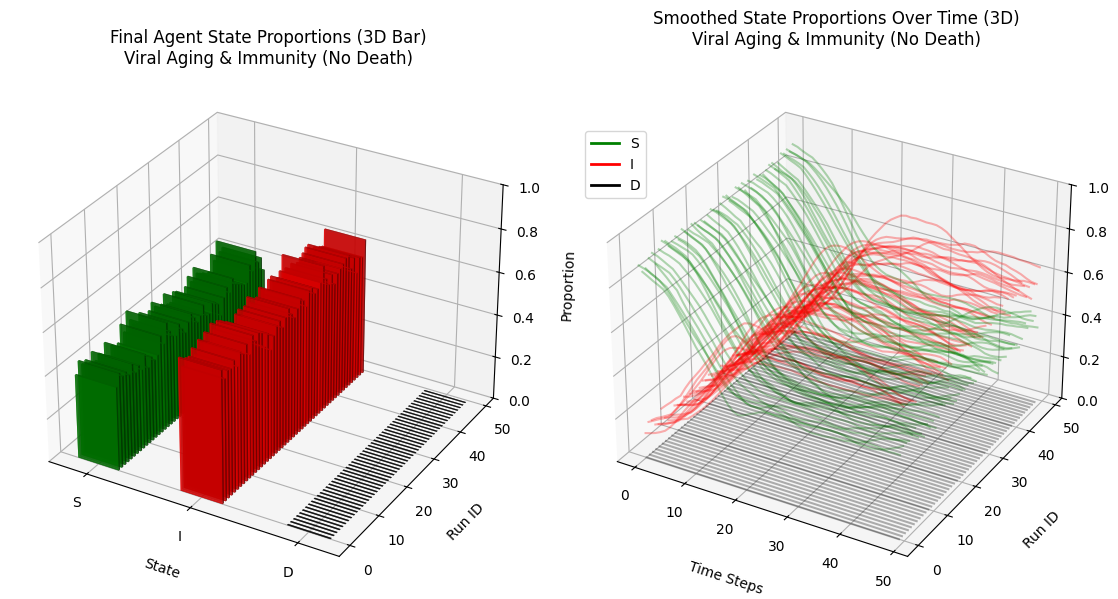

array([4.90000000e+01, 0.00000000e+00, 6.78760000e-01, 2.63238600e+01,
       4.71512000e+00, 1.17052000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.89760000e+02, 8.83160000e+02, 8.98600000e+01,
       7.93300000e+02, 1.80311401e+00])

In [6]:

params_siim = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_siim, steps=SIM_STEPS, title_suffix="Viral Aging & Immunity (No Death)")


# All Mechanics (Death + Aging + Immunity)

Running 50 simulations for All Mechanics...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


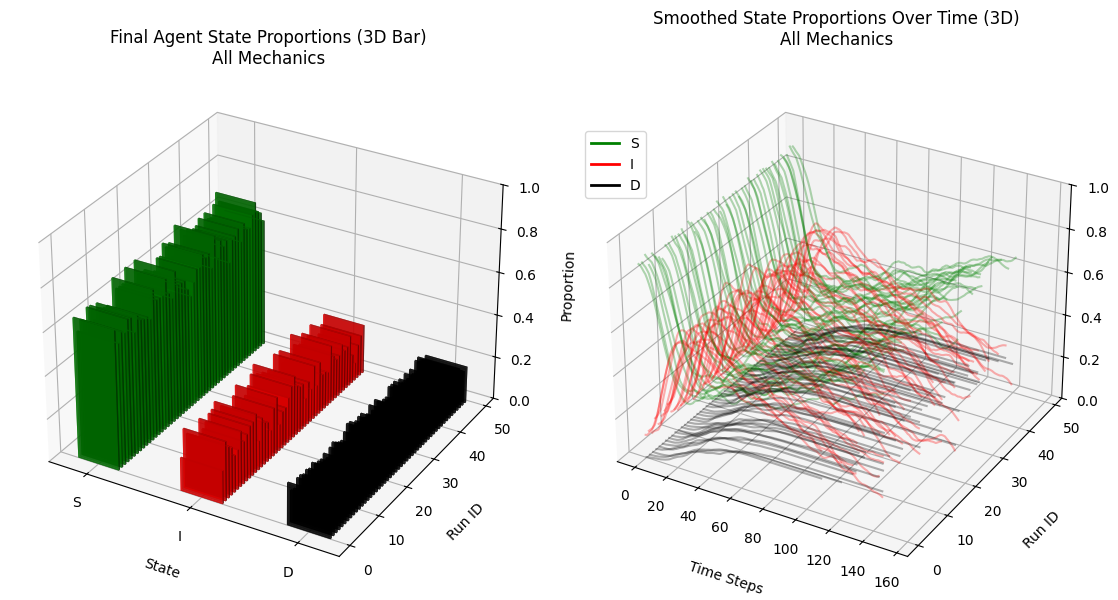

array([1.26140000e+02, 1.72600000e-01, 5.84920000e-01, 4.79138400e+01,
       1.06246000e+01, 2.75216000e+00, 1.68327306e-01, 2.09264366e-01,
       0.00000000e+00, 4.99320000e+02, 1.56352000e+03, 1.56500000e+02,
       1.40702000e+03, 3.13124716e+00])

In [7]:

params_all = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_all, steps=SIM_STEPS, title_suffix="All Mechanics")


# Vax Vulnerable
- vul_penalty=2
- vax_vulnerable=True

Running 50 simulations for Vaccinate Vulnerable...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


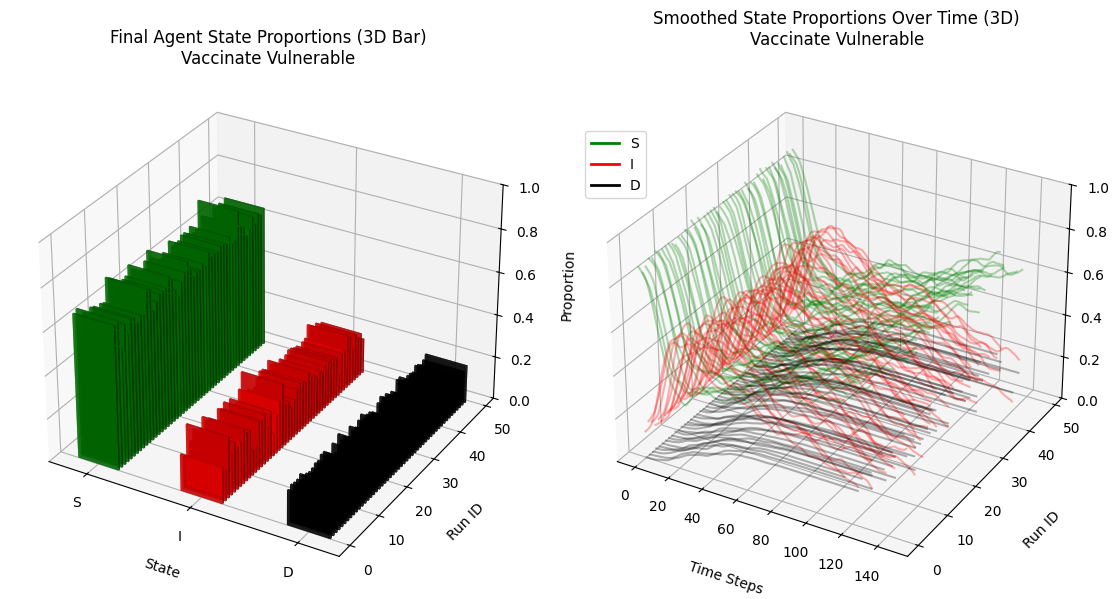

array([1.25420000e+02, 1.62480000e-01, 5.81120000e-01, 4.71661800e+01,
       1.08706400e+01, 2.76796000e+00, 1.66123804e-01, 1.33757741e-01,
       0.00000000e+00, 4.99340000e+02, 1.56572000e+03, 1.72380000e+02,
       1.39334000e+03, 3.13556077e+00])

In [8]:

params_vax_vul = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=2,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=True, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_vax_vul, steps=SIM_STEPS, title_suffix="Vaccinate Vulnerable")


# Vax All
- vul_penalty=2
- vax_all=True
- Reduced aging/immunity (0.05)

Running 50 simulations for Vaccinate All...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_3662/2801700871.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


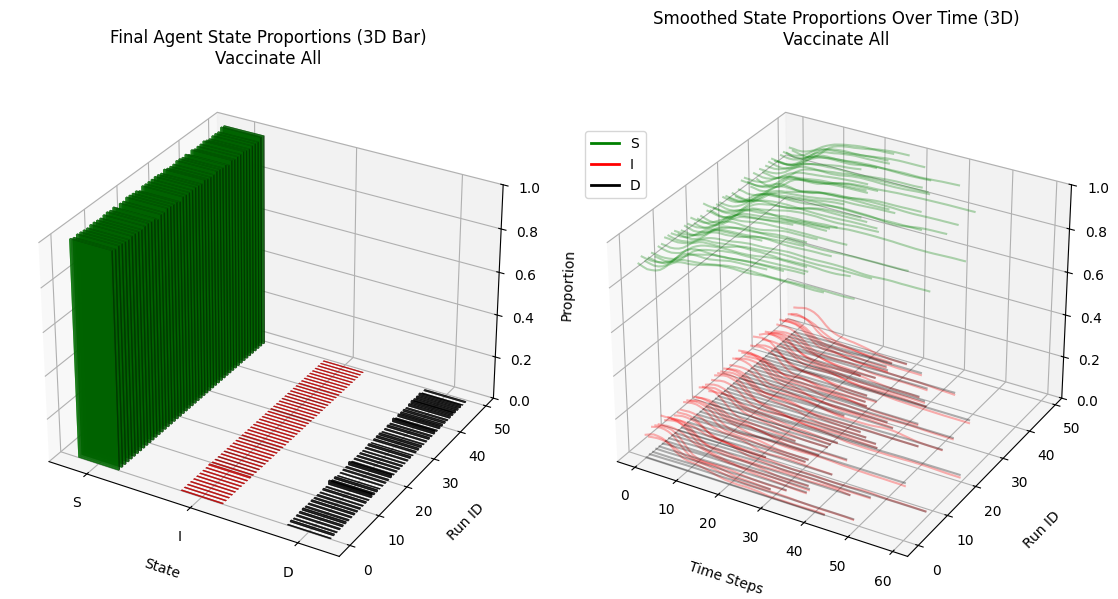

array([3.57600000e+01, 5.84000000e-03, 1.17640000e-01, 1.06756000e+00,
       1.31600000e-01, 1.63320000e-01, 2.23154168e-03, 3.56771140e-02,
       0.00000000e+00, 8.22200000e+01, 8.46200000e+01, 1.29200000e+01,
       7.17000000e+01, 1.02828697e+00])

In [9]:

params_vax_all = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=2,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=True, vax_all=True, vax_effect=0.7,
    viral_age_effect=0.05, immune_adaptation_effect=0.05
)
run_multiple_simulations(N_RUNS, params_vax_all, steps=SIM_STEPS, title_suffix="Vaccinate All")
